# SMMA — Diagnóstico automático de falhas em máquinas rotativas

Este notebook constrói, passo a passo, dois classificadores independentes
capazes de identificar quatro condições de operação de um motor de
indução a partir de sensores de vibração e corrente elétrica:

- **operação normal**
- **desbalanceamento** (massa desbalanceada no rotor)
- **desalinhamento** (eixo motor–carga desalinhado)
- **desgaste de rolamento** (defeito na pista externa/interna do rolamento)

O ponto de partida é o sinal bruto de sensores reais — quatro canais de
vibração (dois acelerômetros biaxiais, um por mancal) e uma corrente de
fase — amostrados a 25.600&nbsp;Hz num banco de ensaios de bancada, sob
três cargas mecânicas (0, 2 e 4&nbsp;N·m). O notebook percorre todo o
caminho até os dois modelos treinados: um perceptron multicamadas (MLP)
sobre um vetor de features espectrais, e uma rede convolucional (CNN)
sobre espectrogramas.

## 1. Instalação de dependências

Este notebook depende de bibliotecas externas (NumPy, pandas, SciPy,
DuckDB, PyArrow, Matplotlib, nptdms — lista completa em
`requirements.txt`). A célula abaixo instala tudo no mesmo ambiente
Python que está rodando este kernel; se já estiverem instaladas, o
`pip` não faz nada. Rode esta célula uma vez antes de seguir.

In [ ]:
import subprocess
import sys
from pathlib import Path

for _candidate in [Path.cwd(), Path.cwd().parent, Path.cwd().parent.parent]:
    if (_candidate / "requirements.txt").exists():
        _requirements_path = _candidate / "requirements.txt"
        break
else:
    raise RuntimeError(
        "requirements.txt não encontrado -- execute este notebook a partir "
        "de 03.Reference ou 03.Reference/notebooks"
    )

_result = subprocess.run(
    [sys.executable, "-m", "pip", "install", "-r", str(_requirements_path)],
    cwd=_requirements_path.parent,  # -e . in requirements.txt resolves against
                                     # the process cwd, not the file's own folder
    capture_output=True, text=True,
)
if _result.returncode != 0:
    print(_result.stdout)
    print(_result.stderr)
    raise RuntimeError(
        f"pip install falhou (código {_result.returncode}) -- veja a saída "
        "completa do pip acima para o motivo real"
    )
print(f"Dependências instaladas a partir de {_requirements_path}")

In [ ]:
import sys
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import decimate

for candidate in [Path.cwd(), Path.cwd().parent, Path.cwd().parent.parent]:
    if (candidate / "fft" / "reference.py").exists():
        sys.path.insert(0, str(candidate))
        break
else:
    raise RuntimeError("execute este notebook a partir de 03.Reference ou 03.Reference/notebooks")

from dataset.paths import PROJECT_ROOT, DATASET_DIR, RAW_DATASET_DIR
from dataset.signal_params import (
    FS_HZ, N_FFT, VIBRATION_INGESTION_SCALE, CURRENT_INGESTION_SCALE, normalize_ingestion,
)
from fft.reference import fft_dif_radix2, unscramble, magnitude_spectrum, top_3_local_maxima
from mdc.reference import estimate_fundamental_from_peaks
from matrix_inv.motor_parameters import refine_f0_hz
from features.pipeline import (
    extract_features as extract_features_v1, BLOCK_SAMPLES, VIBRATION_CHANNEL_SCALES,
)
from features.pipeline_v2 import extract_features as extract_features_v2
from ml_classifier.reference import N_FEATURES as MLP_V1_N_FEATURES
from ml_classifier.reference_v2 import (
    CLASS_NAMES, FEATURE_NAMES as MLP_FEATURE_NAMES, N_FEATURES as MLP_N_FEATURES,
    init_weights as mlp_init_weights, compute_loss_and_grads as mlp_loss_grads,
    apply_gradient_step as mlp_apply_step, forward as mlp_forward,
)
from cnn.reference import (
    build_lowfreq_spectrogram_multichannel, LOWFREQ_BLOCK_SAMPLES,
    init_weights as cnn_init_weights, compute_loss_and_grads_batched as cnn_loss_grads,
    apply_gradient_step as cnn_apply_step, predict_batched as cnn_predict,
)
from build_dataset import load_mat_signal, load_tdms_channels

# Raw .mat (vibration) and .tdms (current/temperature) files live together
# in one flat directory -- see dataset/paths.py.
VIBRATION_DIR = RAW_DATASET_DIR
CURRENT_DIR = RAW_DATASET_DIR
CURRENT_CHANNEL_NAME = "corrente_fase_u"
CLASS_COLORS = {
    "operacao_normal": "#2f7a3d",
    "desbalanceamento": "#a85f18",
    "desalinhamento": "#7a3fa8",
    "desgaste_rolamento": "#b3402f",
}
EXAMPLE_STEMS = {
    "operacao_normal": "0Nm_Normal",
    "desbalanceamento": "0Nm_Unbalance_1169mg",
    "desalinhamento": "0Nm_Misalign_03",
    "desgaste_rolamento": "0Nm_BPFO_10",
}

plt.rcParams["figure.dpi"] = 110


def load_source(stem):
    """Carrega vibração (4 canais) e corrente de fase de uma gravação."""
    vib = load_mat_signal(VIBRATION_DIR / f"{stem}.mat").values  # (n_amostras, 4)
    cur_channels = load_tdms_channels(CURRENT_DIR / f"{stem}.tdms")
    cur_ch = next(c for c in cur_channels if c.column_name == CURRENT_CHANNEL_NAME)
    return vib, cur_ch.values


print("Ambiente pronto. Raiz do projeto:", PROJECT_ROOT)

Ambiente pronto. Raiz do projeto: C:\Temp\Industrial_Monitoring_Accelerator


## 2. Importação do dataset

Os dados brutos (`.mat`/`.tdms`, ~3GB) não ficam versionados no
repositório — são baixados de um [dataset público no
Mendeley](https://data.mendeley.com/datasets/ztmf3m7h5x) na primeira
execução. A célula abaixo baixa o arquivo (se `07.Datasets/` ainda não
tiver os `.mat`/`.tdms`), extrai e monta toda a cadeia de dados
processados (split, k-fold, features, espectrogramas) que este notebook
usa. Se os arquivos já existirem, cada etapa é pulada — repetir a
execução depois é seguro e rápido.

In [ ]:
from tools.bootstrap_dataset import ensure_dataset_ready

ensure_dataset_ready()

  -> C:\Temp\Industrial_Monitoring_Accelerator\07.Datasets\_dataset_download.zip
  6 MB / 4,252 MB (0%)
  16 MB / 4,252 MB (0%)
  37 MB / 4,252 MB (1%)
  59 MB / 4,252 MB (1%)
  82 MB / 4,252 MB (2%)
  106 MB / 4,252 MB (2%)
  129 MB / 4,252 MB (3%)
  152 MB / 4,252 MB (4%)
  175 MB / 4,252 MB (4%)
  196 MB / 4,252 MB (5%)
  219 MB / 4,252 MB (5%)
  244 MB / 4,252 MB (6%)
  269 MB / 4,252 MB (6%)
  292 MB / 4,252 MB (7%)
  314 MB / 4,252 MB (7%)
  338 MB / 4,252 MB (8%)
  363 MB / 4,252 MB (9%)
  389 MB / 4,252 MB (9%)
  414 MB / 4,252 MB (10%)
  439 MB / 4,252 MB (10%)
  466 MB / 4,252 MB (11%)
  494 MB / 4,252 MB (12%)
  525 MB / 4,252 MB (12%)
  562 MB / 4,252 MB (13%)
  606 MB / 4,252 MB (14%)
  633 MB / 4,252 MB (15%)
  663 MB / 4,252 MB (16%)
  693 MB / 4,252 MB (16%)
  724 MB / 4,252 MB (17%)
  753 MB / 4,252 MB (18%)
  778 MB / 4,252 MB (18%)
  804 MB / 4,252 MB (19%)
  833 MB / 4,252 MB (20%)
  863 MB / 4,252 MB (20%)
  892 MB / 4,252 MB (21%)
  924 MB / 4,252 MB (22%)
  948 M

## 3. O dataset

45 gravações no total, cada uma um ensaio de bancada sob uma combinação
de (condição de falha, severidade, carga). A tabela abaixo resume quantas
gravações e severidades cada classe tem — o desbalanceamento de classes é
real e vai ser relevante mais adiante: **`operação normal` tem apenas 3
gravações no dataset inteiro**, uma por carga, sem variação de severidade.

| Classe | Gravações | Severidades |
|---|---|---|
| `operacao_normal` | 3 | — (1 por carga) |
| `desbalanceamento` | 15 | 5 massas × 3 cargas |
| `desalinhamento` | 9 | 3 níveis × 3 cargas |
| `desgaste_rolamento` | 18 | 6 combinações (pista externa/interna) × 3 cargas |

Carregando uma gravação de exemplo (operação normal) para ilustrar os
próximos passos:

In [ ]:
vib_normal, cur_normal = load_source(EXAMPLE_STEMS["operacao_normal"])
print(f"vibração: {vib_normal.shape[0]:,} amostras × {vib_normal.shape[1]} canais "
      f"({vib_normal.shape[0]/FS_HZ:.1f}s a {FS_HZ:.0f}Hz)")

vibração: 7,680,000 amostras × 4 canais (300.0s a 25600Hz)


## 4. Do sinal bruto ao sinal utilizável — normalização de ingestão

Os sensores entregam valores em unidades físicas, com amplitudes bem
diferentes entre canais. Antes de qualquer processamento (filtragem,
FFT), cada canal passa por uma normalização própria — divide-se pela
amplitude máxima esperada daquele canal e recorta-se em [-1, 1]. Isso
mantém todo o pipeline numa faixa numérica estável, o que importa tanto
para os algoritmos adaptativos quanto para uma futura implementação em
ponto fixo.

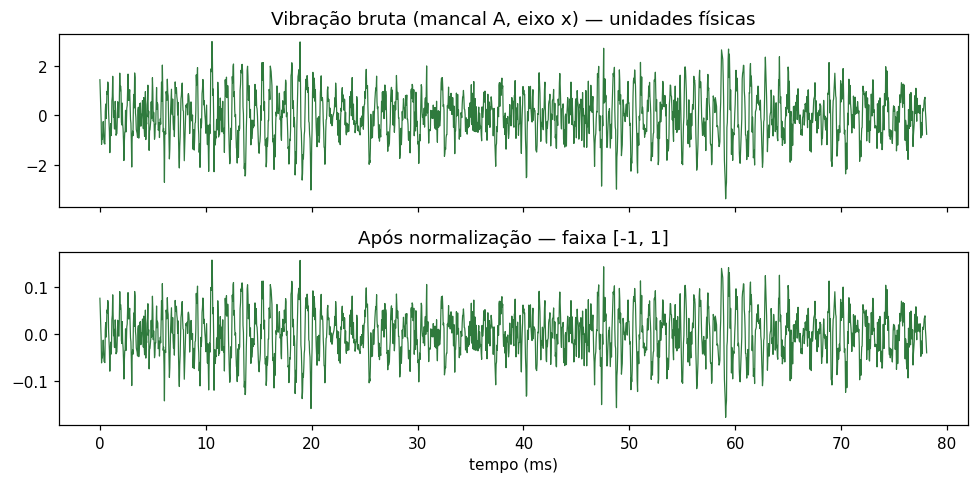

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(9, 4.5), sharex=True)
t_ms = np.arange(2000) / FS_HZ * 1000
axes[0].plot(t_ms, vib_normal[:2000, 0], lw=0.8, color=CLASS_COLORS["operacao_normal"])
axes[0].set_title("Vibração bruta (mancal A, eixo x) — unidades físicas")
axes[1].plot(t_ms, normalize_ingestion(vib_normal[:2000, 0], VIBRATION_INGESTION_SCALE),
             lw=0.8, color=CLASS_COLORS["operacao_normal"])
axes[1].set_title("Após normalização — faixa [-1, 1]")
axes[1].set_xlabel("tempo (ms)")
plt.tight_layout()
plt.show()

## 5. Expondo os harmônicos de rotação — decimação

A vibração de um eixo girando a ~50Hz produz energia concentrada em
harmônicos dessa frequência (1×, 2×, 3× a rotação) — é exatamente essa
energia que distingue desbalanceamento de desalinhamento. O problema:
com a taxa de amostragem original e uma FFT de 64 pontos, cada bin de
frequência cobre 400Hz de largura — os harmônicos de rotação (50/100/
150Hz) caem todos dentro do primeiro bin (DC), que é descartado.

Decimando o sinal por 64 antes da FFT, a mesma FFT de 64 pontos passa a
cobrir só 0–200Hz, com bins de 6,25Hz — os harmônicos aparecem como
picos distintos e resolvíveis.

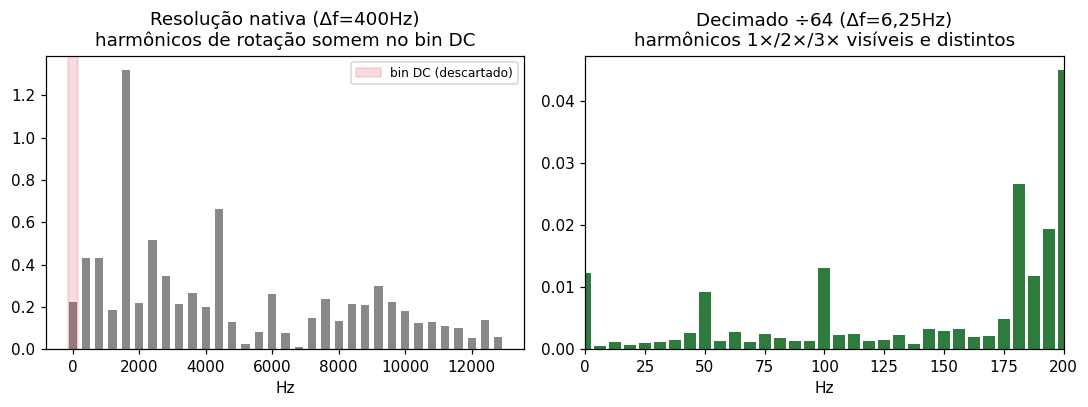

In [ ]:
BLOCK_NATIVE = 2048
seg_native = normalize_ingestion(vib_normal[:BLOCK_NATIVE, 0], VIBRATION_INGESTION_SCALE)
native_spec = magnitude_spectrum(unscramble(fft_dif_radix2(seg_native[:N_FFT])))

seg_dec_block = normalize_ingestion(vib_normal[:BLOCK_SAMPLES, 0], VIBRATION_INGESTION_SCALE)
dec = decimate(seg_dec_block, 64, ftype="fir")
dec_spec = magnitude_spectrum(unscramble(fft_dif_radix2(dec[:N_FFT])))

fig, axes = plt.subplots(1, 2, figsize=(10, 3.8))
freqs_native = np.arange(len(native_spec)) * (FS_HZ / N_FFT)
axes[0].bar(freqs_native, native_spec, width=250, color="#888")
axes[0].axvspan(-150, 150, color="crimson", alpha=0.15, label="bin DC (descartado)")
axes[0].set_title("Resolução nativa (Δf=400Hz)\nharmônicos de rotação somem no bin DC")
axes[0].set_xlabel("Hz")
axes[0].legend(fontsize=8)

freqs_dec = np.arange(len(dec_spec)) * (FS_HZ / 64 / N_FFT)
axes[1].bar(freqs_dec, dec_spec, width=5, color=CLASS_COLORS["operacao_normal"])
axes[1].set_title("Decimado ÷64 (Δf=6,25Hz)\nharmônicos 1×/2×/3× visíveis e distintos")
axes[1].set_xlabel("Hz")
axes[1].set_xlim(0, 200)
plt.tight_layout()
plt.show()

## 6. Estimando a frequência fundamental do eixo (f0)

A corrente de fase carrega uma assinatura elétrica ligada à rotação do
eixo. Para estimar f0: FFT da corrente decimada, detecção dos picos
espectrais e um algoritmo baseado em máximo divisor comum (MDC) para
achar a frequência fundamental a partir de picos harmônicos — com um
atalho prático quando um único pico já domina claramente o espectro
(o caso mais comum neste sinal).

A frequência resultante ainda está limitada à resolução de um bin da
FFT. Um refinamento sub-bin — ajustar uma parábola pelos três pontos ao
redor do pico e resolver o sistema linear resultante — melhora essa
estimativa sem custo adicional de hardware relevante.

f0 quantizado por bin:  50.000 Hz
f0 refinado (sub-bin):  49.982 Hz


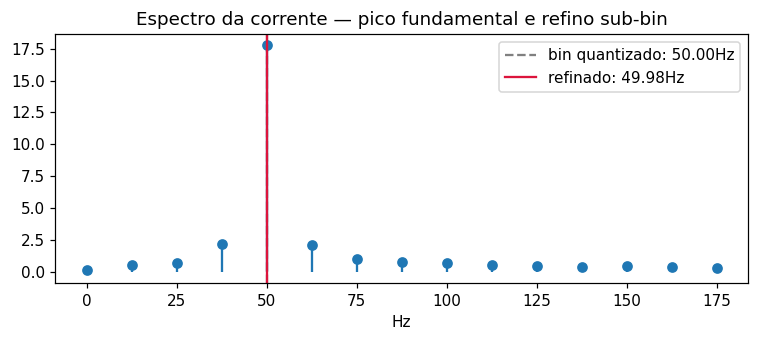

In [ ]:
cur_seg = normalize_ingestion(cur_normal[:BLOCK_SAMPLES], CURRENT_INGESTION_SCALE)
cur_dec = decimate(cur_seg, 32, ftype="fir")
fs_dec = FS_HZ / 32
cur_spec = magnitude_spectrum(unscramble(fft_dif_radix2(cur_dec[:N_FFT])))

peaks = top_3_local_maxima(cur_spec)
result = estimate_fundamental_from_peaks(peaks, fs_dec, N_FFT)
f0_bin = result.k0 * fs_dec / N_FFT
f0_refined = refine_f0_hz(cur_spec, result.k0, fs_dec, N_FFT)
print(f"f0 quantizado por bin:  {f0_bin:.3f} Hz")
print(f"f0 refinado (sub-bin):  {f0_refined:.3f} Hz")

fig, ax = plt.subplots(figsize=(7, 3.2))
freqs_cur = np.arange(len(cur_spec)) * (fs_dec / N_FFT)
ax.stem(freqs_cur[:15], cur_spec[:15], basefmt=" ")
ax.axvline(f0_bin, color="gray", ls="--", label=f"bin quantizado: {f0_bin:.2f}Hz")
ax.axvline(f0_refined, color="crimson", label=f"refinado: {f0_refined:.2f}Hz")
ax.set_xlabel("Hz")
ax.set_title("Espectro da corrente — pico fundamental e refino sub-bin")
ax.legend()
plt.tight_layout()
plt.show()

## 7. O vetor de features do classificador MLP

Cada bloco de sinal (~160ms) vira um vetor de números: a frequência
fundamental refinada, mais o espectro de baixa frequência (32 bins úteis)
de cada um dos 4 canais de vibração — 129 valores no total. Uma segunda
versão do vetor acrescenta 4 coeficientes de um modelo autorregressivo
(AR) ajustado sobre a vibração de um dos canais, resolvidos pelo mesmo
tipo de sistema linear usado no refino de f0 — 133 valores.

As duas versões são mantidas vivas lado a lado (chamadas aqui de v1 e
v2): a segunda usa mais informação e, como vamos ver na comparação
final, generaliza melhor.

In [ ]:
vib_blocks = [vib_normal[:BLOCK_SAMPLES, c] for c in range(4)]
fv1 = extract_features_v1(vib_blocks, cur_normal[:BLOCK_SAMPLES])
fv2 = extract_features_v2(vib_blocks, cur_normal[:BLOCK_SAMPLES])

print(f"vetor v1: {MLP_V1_N_FEATURES} valores  |  vetor v2: {MLP_N_FEATURES} valores")
print(f"f0 refinado: {fv1.f0_hz:.2f} Hz")
print(f"primeiros 6 bins do espectro de baixa freq. (mancal A, eixo x): "
      f"{np.round(fv1.lowfreq_spectrum[:6], 4)}")
print(f"coeficientes AR (só na v2): {np.round(fv2.ar_coefficients, 4)}")

vetor v1: 129 valores  |  vetor v2: 133 valores
f0 refinado: 49.98 Hz
primeiros 6 bins do espectro de baixa freq. (mancal A, eixo x): [0.0005 0.0012 0.0007 0.001  0.0012 0.0015]
coeficientes AR (só na v2): [-0.7226 -0.1536 -0.467  -0.1538]


## 8. Como cada falha se manifesta no espectro

Carregando uma gravação representativa de cada classe para comparar a
assinatura espectral. A expectativa física: desbalanceamento concentra
energia no 1º harmônico da rotação (bin 8, ~50Hz); desalinhamento no 3º
harmônico (bin 24, ~150Hz). Desgaste de rolamento já se separa por
energia bruta muito mais alta em toda a banda — não precisa de uma
distinção fina por bin.

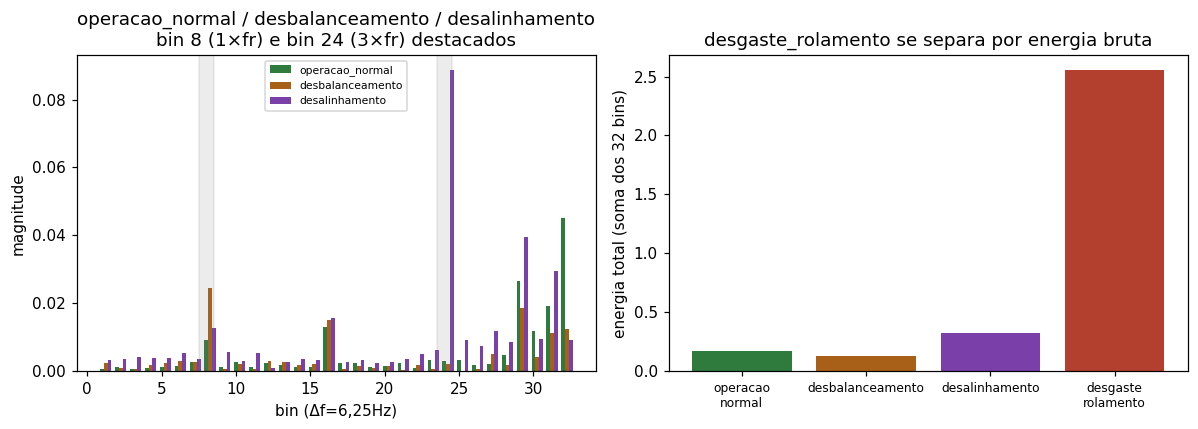

In [ ]:
class_lowfreq = {}
for label, stem in EXAMPLE_STEMS.items():
    vib, _ = load_source(stem)
    blk = normalize_ingestion(vib[:BLOCK_SAMPLES, 0], VIBRATION_INGESTION_SCALE)
    dec = decimate(blk, 64, ftype="fir")
    class_lowfreq[label] = magnitude_spectrum(unscramble(fft_dif_radix2(dec[:N_FFT])))[1:33]

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

subtle_classes = [c for c in EXAMPLE_STEMS if c != "desgaste_rolamento"]
x = np.arange(1, 33)
width = 0.25
for i, label in enumerate(subtle_classes):
    axes[0].bar(x + i * width, class_lowfreq[label], width=width, label=label, color=CLASS_COLORS[label])
axes[0].axvspan(7.5, 8.5, color="gray", alpha=0.15)
axes[0].axvspan(23.5, 24.5, color="gray", alpha=0.15)
axes[0].set_xlabel("bin (Δf=6,25Hz)")
axes[0].set_ylabel("magnitude")
axes[0].set_title("operacao_normal / desbalanceamento / desalinhamento\nbin 8 (1×fr) e bin 24 (3×fr) destacados")
axes[0].legend(fontsize=7)

all_classes = list(EXAMPLE_STEMS)
totals = [class_lowfreq[c].sum() for c in all_classes]
axes[1].bar(range(4), totals, color=[CLASS_COLORS[c] for c in all_classes])
axes[1].set_xticks(range(4))
axes[1].set_xticklabels([c.replace("_", "\n") for c in all_classes], fontsize=8)
axes[1].set_ylabel("energia total (soma dos 32 bins)")
axes[1].set_title("desgaste_rolamento se separa por energia bruta")
plt.tight_layout()
plt.show()

## 9. Montando o dataset de treino completo

O mesmo processo do bloco de exemplo acima — normalizar, decimar,
extrair o vetor de features — é repetido para todas as 45 gravações,
percorrendo cada uma em blocos sucessivos, gerando muitas linhas de
treino por gravação.

Como `operação normal` tem só 3 gravações, uma janela por bloco sem
sobreposição deixa essa classe com poucas centenas de exemplos — pouco
para uma rede aprender a distinguir "normal" de forma confiável. A
correção adotada: para essa classe (e só para ela) as janelas se
sobrepõem bastante entre si, extraindo várias vezes mais exemplos das
mesmas 3 gravações sem duplicar dado nem inventar informação — como
operação normal é um regime estável no tempo, amostrar mais densamente a
mesma gravação caracteriza melhor a classe, sem custar nada às outras.

Carregando o dataset já construído dessa forma:

label
operacao_normal       13488
desbalanceamento      11235
desalinhamento         6741
desgaste_rolamento     6732
Name: count, dtype: int64


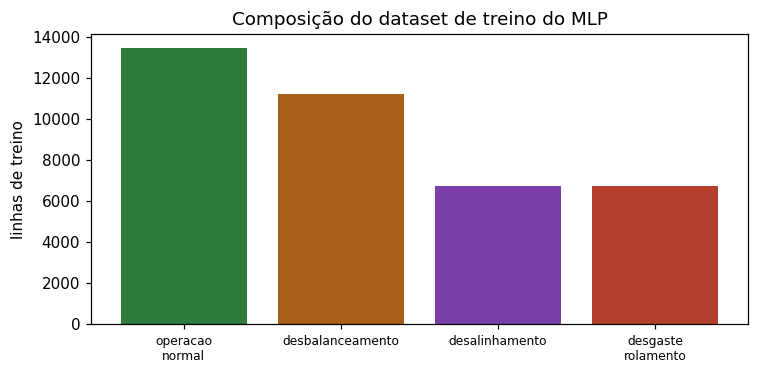

In [ ]:
mlp_df = pd.read_parquet(DATASET_DIR / "features_dataset_v2_dense_normal.parquet")
label_to_index = {name: i for i, name in enumerate(CLASS_NAMES)}
n_classes = len(CLASS_NAMES)

counts = mlp_df["label"].value_counts().reindex(CLASS_NAMES)
print(counts)

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.bar(range(4), counts.values, color=[CLASS_COLORS[c] for c in CLASS_NAMES])
ax.set_xticks(range(4))
ax.set_xticklabels([c.replace("_", "\n") for c in CLASS_NAMES], fontsize=8)
ax.set_ylabel("linhas de treino")
ax.set_title("Composição do dataset de treino do MLP")
plt.tight_layout()
plt.show()

## 10. Treinando o classificador MLP

Arquitetura simples e compatível com implementação em hardware: 129/133
entradas → uma camada oculta de 16 neurônios (ReLU) → 4 saídas, decisão
por argmax (sem softmax — só a classe vencedora importa).

Duas escolhas de treino relevantes:

- **Validação cruzada agrupada por gravação** (*k-fold*, 3 grupos): cada
  gravação inteira vai para um único grupo, nunca dividida entre treino
  e teste — amostras vizinhas da mesma gravação são muito parecidas
  entre si, e misturá-las entre treino/teste inflaria artificialmente a
  métrica.
- **Peso por classe na função de perda**, proporcional ao inverso da
  frequência de cada classe — sem isso, o modelo aprende a ignorar
  `operação normal` simplesmente porque ela é rara.

Treinando os 3 folds e agregando a matriz de confusão:

In [ ]:
def confusion_matrix(y_true, y_pred, n_classes):
    m = np.zeros((n_classes, n_classes), dtype=int)
    for t, p in zip(y_true, y_pred):
        m[t, p] += 1
    return m


def class_weights_from_counts(y, n_classes):
    counts = np.bincount(y, minlength=n_classes)
    inverse = 1.0 / np.maximum(counts, 1)
    return inverse / inverse.sum() * n_classes


def per_class_metrics(matrix, class_names):
    out = {}
    for c, name in enumerate(class_names):
        tp = matrix[c, c]
        support = matrix[c].sum()
        predicted = matrix[:, c].sum()
        recall = tp / support if support else 0.0
        precision = tp / predicted if predicted else 0.0
        f1 = 2 * precision * recall / (precision + recall) if (precision + recall) else 0.0
        out[name] = dict(precision=precision, recall=recall, f1=f1, support=int(support))
    return out


def plot_confusion_and_metrics(matrix, class_names, title):
    metrics = per_class_metrics(matrix, class_names)
    fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))

    norm = matrix / matrix.sum(axis=1, keepdims=True)
    axes[0].imshow(norm, cmap="Blues", vmin=0, vmax=1)
    short = [c.replace("_", "\n") for c in class_names]
    axes[0].set_xticks(range(len(class_names))); axes[0].set_xticklabels(short, fontsize=7)
    axes[0].set_yticks(range(len(class_names))); axes[0].set_yticklabels(short, fontsize=7)
    axes[0].set_xlabel("previsto"); axes[0].set_ylabel("real")
    for i in range(len(class_names)):
        for j in range(len(class_names)):
            axes[0].text(j, i, matrix[i, j], ha="center", va="center",
                         color="white" if norm[i, j] > 0.5 else "black", fontsize=8)
    axes[0].set_title("Matriz de confusão")

    x = np.arange(len(class_names))
    width = 0.35
    axes[1].bar(x - width/2, [metrics[c]["precision"] for c in class_names], width, label="precisão", color="#2f6f9e")
    axes[1].bar(x + width/2, [metrics[c]["recall"] for c in class_names], width, label="recall", color="#c67a2e")
    axes[1].axhline(0.75, color="crimson", ls="--", lw=1, label="referência: 75%")
    axes[1].set_xticks(x); axes[1].set_xticklabels(short, fontsize=7)
    axes[1].set_ylim(0, 1.05); axes[1].legend(fontsize=8)
    axes[1].set_title("Precisão e recall por classe")

    fig.suptitle(title)
    plt.tight_layout()
    plt.show()
    return metrics

fold 0 concluído (26964 treino / 11232 teste) — 35s
fold 1 concluído (26964 treino / 11232 teste) — 68s
fold 2 concluído (22464 treino / 15732 teste) — 97s


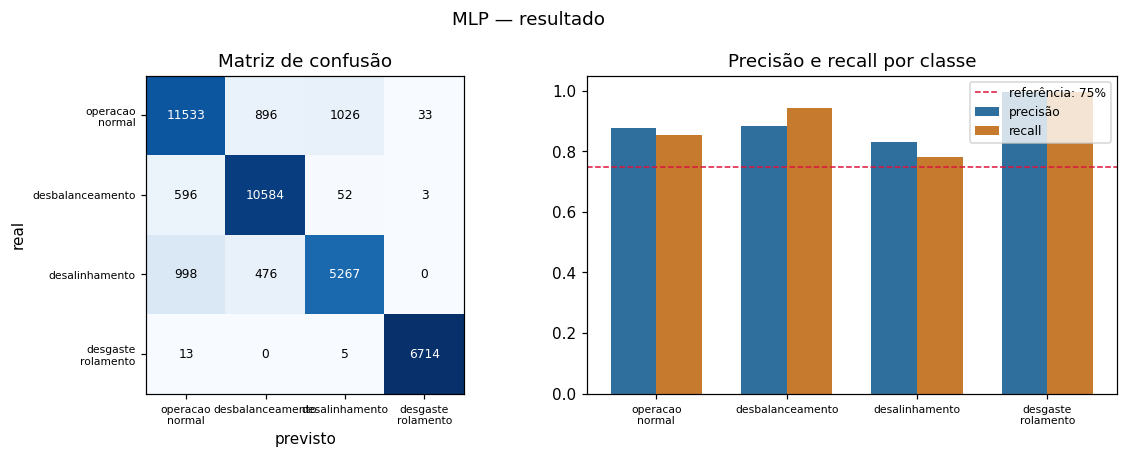

In [ ]:
HIDDEN, EPOCHS_MLP, LR_MLP, SEED = 16, 2000, 0.1, 0
y_all_mlp = mlp_df["label"].map(label_to_index).to_numpy()
total_matrix_mlp = np.zeros((n_classes, n_classes), dtype=int)

t0 = time.time()
for fold in range(3):
    test_mask = (mlp_df["fold"] == fold).to_numpy()
    train_df, test_df = mlp_df[~test_mask], mlp_df[test_mask]

    feat_mean = train_df[MLP_FEATURE_NAMES].to_numpy(dtype=np.float64).mean(axis=0)
    feat_std = train_df[MLP_FEATURE_NAMES].to_numpy(dtype=np.float64).std(axis=0)
    safe_std = np.where(feat_std == 0, 1.0, feat_std)
    x_train = (train_df[MLP_FEATURE_NAMES].to_numpy(dtype=np.float64) - feat_mean) / safe_std
    y_train = train_df["label"].map(label_to_index).to_numpy()
    x_test = (test_df[MLP_FEATURE_NAMES].to_numpy(dtype=np.float64) - feat_mean) / safe_std
    y_test = test_df["label"].map(label_to_index).to_numpy()

    sample_w = class_weights_from_counts(y_train, n_classes)[y_train]
    weights = mlp_init_weights(n_hidden=HIDDEN, seed=SEED + fold)
    for _ in range(EPOCHS_MLP):
        _, _, grads = mlp_loss_grads(x_train, y_train, weights, sample_weights=sample_w)
        weights = mlp_apply_step(weights, grads, learning_rate=LR_MLP)

    y_pred = np.array([mlp_forward(x, weights)[1] for x in x_test])
    total_matrix_mlp += confusion_matrix(y_test, y_pred, n_classes)
    print(f"fold {fold} concluído ({len(train_df)} treino / {len(test_df)} teste) — {time.time()-t0:.0f}s")

mlp_metrics = plot_confusion_and_metrics(total_matrix_mlp, CLASS_NAMES, "MLP — resultado")

## 11. O espectrograma para a CNN

A segunda arquitetura recebe uma representação diferente: em vez de um
vetor de números, uma pequena imagem 32×32 — cada coluna é o espectro de
uma janela de tempo, empilhadas lado a lado. A rede convolucional aprende
seus próprios filtros sobre essa imagem, em vez de features desenhadas à
mão.

Essa CNN usa apenas os dois canais de um dos mancais (não os 4 canais de
vibração do MLP): testes com mais canais aumentam o número de parâmetros
da rede sem aumentar a quantidade de gravações disponíveis para treiná-
la, e a classe mais rara (`operação normal`) piora por overfitting.

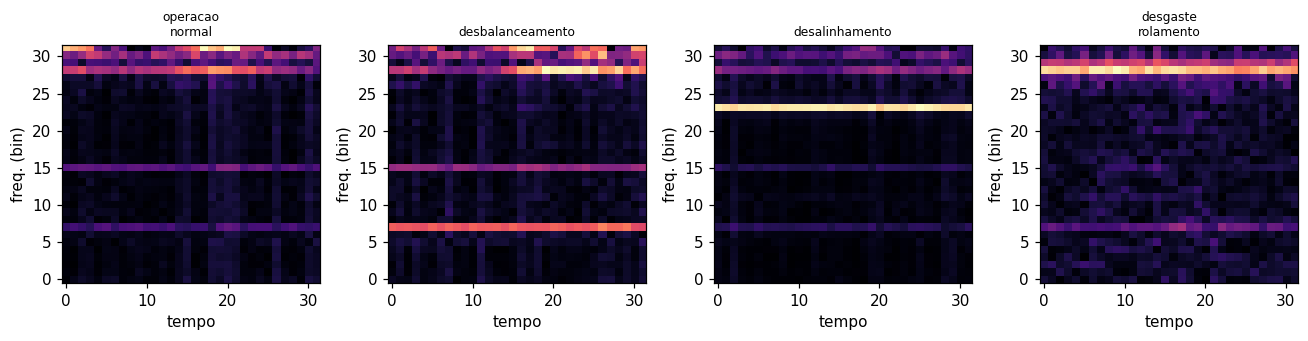

In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(12, 3.2))
for ax, (label, stem) in zip(axes, EXAMPLE_STEMS.items()):
    vib, _ = load_source(stem)
    blocks = [normalize_ingestion(vib[:LOWFREQ_BLOCK_SAMPLES, ch], VIBRATION_CHANNEL_SCALES[ch]) for ch in (0, 1)]
    spec = build_lowfreq_spectrogram_multichannel(blocks)
    ax.imshow(spec[0], aspect="auto", origin="lower", cmap="magma")
    ax.set_title(label.replace("_", "\n"), fontsize=8)
    ax.set_xlabel("tempo"); ax.set_ylabel("freq. (bin)")
plt.tight_layout()
plt.show()

## 12. Treinando a CNN

Arquitetura: uma camada convolucional (8 filtros 3×3) com ReLU, seguida
de max-pooling e uma camada densa para as 4 classes — mesma decisão por
argmax do MLP. Mesma disciplina de validação (k-fold agrupado por
gravação) e mesmo peso por classe.

espectrogramas: (4328, 2, 32, 32)
fold 0 concluído (3057 treino / 1271 teste) — 240s
fold 1 concluído (3057 treino / 1271 teste) — 477s
fold 2 concluído (2542 treino / 1786 teste) — 674s


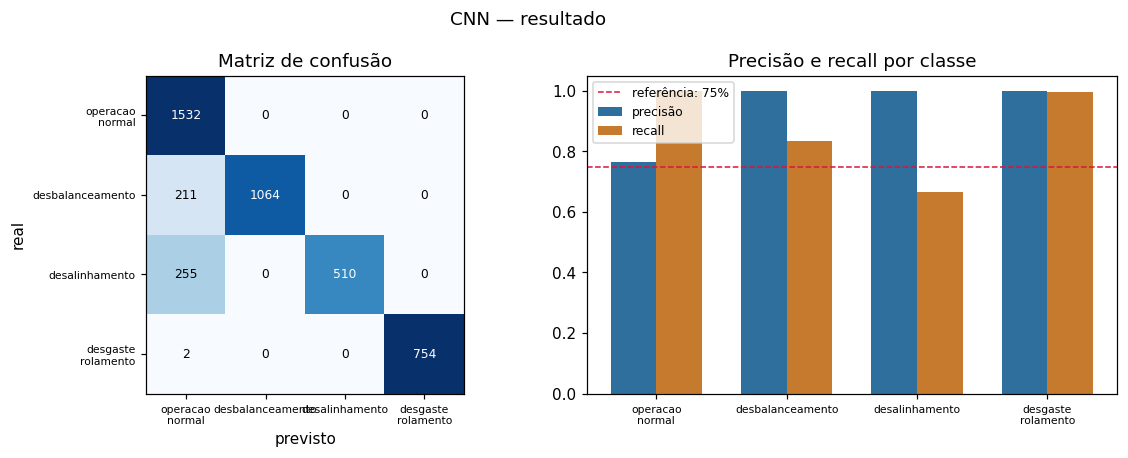

In [ ]:
cnn_data = np.load(DATASET_DIR / "spectrogram_dataset_lowfreq_ch0-1_dense_normal.npz", allow_pickle=True)
x_all_cnn = cnn_data["x"]
y_all_cnn = np.array([label_to_index[l] for l in cnn_data["label"]])
fold_all_cnn = cnn_data["fold"]
print("espectrogramas:", x_all_cnn.shape)

EPOCHS_CNN, LR_CNN = 150, 0.01
total_matrix_cnn = np.zeros((n_classes, n_classes), dtype=int)
n_channels_cnn = x_all_cnn.shape[1]

t0 = time.time()
for fold in range(3):
    test_mask = fold_all_cnn == fold
    x_train, y_train = x_all_cnn[~test_mask], y_all_cnn[~test_mask]
    x_test, y_test = x_all_cnn[test_mask], y_all_cnn[test_mask]

    x_mean, x_std = x_train.mean(), x_train.std()
    x_train_n = (x_train - x_mean) / x_std
    x_test_n = (x_test - x_mean) / x_std

    sample_w = class_weights_from_counts(y_train, n_classes)[y_train]
    weights = cnn_init_weights(n_channels=n_channels_cnn, seed=SEED + fold)
    for _ in range(EPOCHS_CNN):
        _, _, grads = cnn_loss_grads(x_train_n, y_train, weights, sample_weights=sample_w)
        weights = cnn_apply_step(weights, grads, learning_rate=LR_CNN)

    y_pred = cnn_predict(x_test_n, weights)
    total_matrix_cnn += confusion_matrix(y_test, y_pred, n_classes)
    print(f"fold {fold} concluído ({len(x_train)} treino / {len(x_test)} teste) — {time.time()-t0:.0f}s")

cnn_metrics = plot_confusion_and_metrics(total_matrix_cnn, CLASS_NAMES, "CNN — resultado")

## 13. Comparando os dois modelos

Os dois classificadores foram desenvolvidos e avaliados de forma
independente — nenhuma decisão de combiná-los foi tomada. Colocando os
dois lado a lado, por classe:

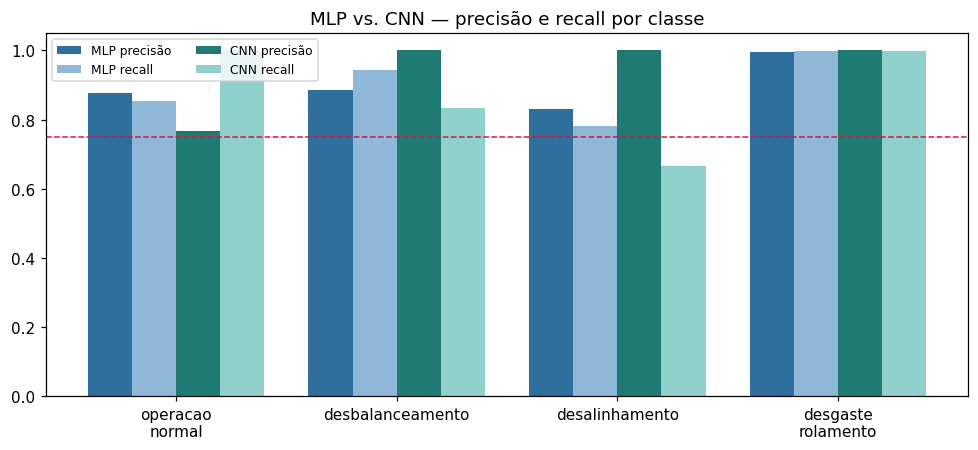

In [ ]:
fig, ax = plt.subplots(figsize=(9, 4.2))
x = np.arange(4)
width = 0.2
ax.bar(x - 1.5*width, [mlp_metrics[c]["precision"] for c in CLASS_NAMES], width, label="MLP precisão", color="#2f6f9e")
ax.bar(x - 0.5*width, [mlp_metrics[c]["recall"] for c in CLASS_NAMES], width, label="MLP recall", color="#8fb7d8")
ax.bar(x + 0.5*width, [cnn_metrics[c]["precision"] for c in CLASS_NAMES], width, label="CNN precisão", color="#1f7a74")
ax.bar(x + 1.5*width, [cnn_metrics[c]["recall"] for c in CLASS_NAMES], width, label="CNN recall", color="#8fd0ca")
ax.axhline(0.75, color="crimson", ls="--", lw=1)
ax.set_xticks(x); ax.set_xticklabels([c.replace("_", "\n") for c in CLASS_NAMES])
ax.set_ylim(0, 1.05)
ax.legend(fontsize=8, ncol=2)
ax.set_title("MLP vs. CNN — precisão e recall por classe")
plt.tight_layout()
plt.show()

## 14. Conclusão

Os dois modelos, treinados de forma independente sobre representações
diferentes do mesmo sinal, chegam a um diagnóstico com precisão e
recall acima de 75% na maior parte das combinações classe/modelo. A
única exceção é `desalinhamento` na CNN, que fica em torno de 67% de
recall — uma limitação dada pela configuração utilizada no cnn vs dados do dataset: a informação que
distingue essa classe está concentrada no mancal que essa CNN não
enxerga; o MLP, que usa os 4 canais, não tem essa lacuna.
